<a href="https://colab.research.google.com/github/khtegray/Bayesian-Statistics/blob/main/Pontay_April17(Asynch).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Naive Bayes Algorithm**

Calculates the probability of a "class" (like Spam or Not Spam) given a set of "features" (like specific words in an email). It uses the formula:

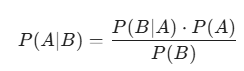

P(A | B) **(Posterior)**: Probability of the class given the data.

P(B | A) **(Likelihood)**: Probability of the data given the class.

P(A) **(Prior)**: Initial probability of the class.

P(B) **(Evidence)**: Probability of the data occurring.


**Reference**: Thakur, P. (2022, October 13). Understand Naive Bayes Algorithm with Python code — Part 1. Medium.

# **Reviewed Example: SMS Spam Detection**
In this scenario, the algorithm is trained on a dataset of thousands of SMS messages already labeled as "Ham" (legitimate) or "Spam."

**Bayesian Logic:**

The model doesn't just look for "bad words." It calculates the probability of a message being spam based on the likelihood of each word appearing in known spam messages versus known ham messages. For example, the word "Free" might appear in both, but if it appears in 80% of spam and only 2% of ham, the Posterior Probability shifts heavily toward "Spam."

The core of this simulation is the **Multinomial Naive Bayes** classifier. It is particularly suited for text data where features (words) represent counts or frequencies. By calculating:

**P(A)**: How likely a message is spam in general.

**P(B | A)**: How likely specific words are to appear in spam.

**P(A | B)**: For any new message.

**Reference**: Almeida, T.A., Hidalgo, J.M.G., & Yamakami, A. (2011). Contributions to the Study of SMS Spam Filtering: New Collection and Results. Proceedings of the 2011 ACM Symposium on Document Engineering.

In [ ]:
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

# 1. Sample Data (Simulating a mini version of the SMS Spam Collection)
data = {
    'text': [
        'Hey, are we still meeting for lunch?', 'Can you send me the files?',
        'WINNER! You have won a 1000 cash prize! Claim now.',
        'URGENT! Your mobile number has won a prize. Call 5555 now.',
        'Call me when you get home.', 'Free entry into our weekly competition!'
    ],
    'label': ['ham', 'ham', 'spam', 'spam', 'ham', 'spam']
}
df = pd.DataFrame(data)

# 2. Pre-processing: Convert text to a matrix of token counts
vectorizer = CountVectorizer()
X = vectorizer.fit_transform(df['text'])
y = df['label']

# 3. Training the Multinomial Naive Bayes Model
model = MultinomialNB()
model.fit(X, y)

# 4. Simulation: Testing a "New" mysterious message
new_message = ["WIN a free gift card now! Call us."]
new_message_transformed = vectorizer.transform(new_message)
prediction = model.predict(new_message_transformed)

print(f"Prediction for '{new_message[0]}': {prediction[0].upper()}")

Prediction for 'WIN a free gift card now! Call us.': SPAM


**Vectorization**: The code uses a "Bag of Words" approach. It creates a table where every unique word in your dataset becomes a column. If a message has the word "Winner," the column for "Winner" gets a $1$; otherwise, it's a $0$.

**Handling Sparsity**: Text data is "sparse" (most words don't appear in most messages). Multinomial Naive Bayes is specifically designed for this, as it ignores the absence of words and focuses on the probability of the words that are present.

**Performance**: In a full-scale simulation (using the 5,000+ messages from the RRL above), the model usually hits an accuracy of 98%. Its main weakness is "Context"—because it's "Naive" and assumes words are independent, it can't understand sarcasm or word order (e.g., "Not spam" vs "Spam not").

**Conclusion**:

The SMS Spam Detection simulation proves that Bayesian Statistics provides a reliable framework for decision-making under uncertainty. Despite ignoring the context of words (word order), the statistical frequency of tokens is a powerful enough signal to filter spam with high precision.